In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## ESTRUCTURA CODIGO PARA CARGAR DATOS Y VISUALIZARLOS
### CREACION DE LA CLASE EnergyDataLoader

In [2]:
class EnergyDataLoader:
    def __init__(self, ruta_archivo):
        self.ruta_archivo = ruta_archivo
        self.df_eb = None

    def load_xls_data(self):
        self.df_eb = pd.read_excel(self.ruta_archivo)

    def show_data_frame(self):
        if self.df_eb is None or self.df_eb.empty:
            print("No se cargaron los datos.")
        else:
            print("Datos listos para mostrar. Mostrar las primeras 5 filas.")
            print(self.df_eb.head())
            

    def data_info(self):
        print(self.df_eb.info())        

In [3]:
ruta = "Dados brutos.xlsx"
data_01 = EnergyDataLoader(ruta)
data_01.load_xls_data()


In [4]:
data_01.show_data_frame()

Datos listos para mostrar. Mostrar las primeras 5 filas.
       Data TipoConsumidor                 Sistema  UF Setor Econômico - N1  \
0  20140101         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
1  20140201         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
2  20140301         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
3  20140401         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
4  20140501         Cativo  Sudeste / Centro-Oeste  RO          Residencial   

                 Setor Econômico - N2 Setor Econômico - N3 Tipo Tensão - N1  \
0  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
1  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
2  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
3  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
4  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tens

In [5]:
data_01.data_info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Data                  285499 non-null  int64  
 1   TipoConsumidor        285499 non-null  object 
 2   Sistema               285499 non-null  object 
 3   UF                    285499 non-null  object 
 4   Setor Econômico - N1  285499 non-null  object 
 5   Setor Econômico - N2  285499 non-null  object 
 6   Setor Econômico - N3  285499 non-null  object 
 7   Tipo Tensão - N1      285499 non-null  object 
 8   Tipo Tensão - N2      285499 non-null  object 
 9   Tipo Tensão - N3      285499 non-null  object 
 10  Faixa de Consumo N1   285499 non-null  object 
 11  Faixa de Consumo N2   285499 non-null  object 
 12  Consumidores          281511 non-null  float64
 13  Consumo               275799 non-null  float64
dtypes: float64(2), int64(1), object(11)
memory usage: 30

## ESTRUCTURA DE CODIGO PARA LIMPIEZA DE DATOS

In [6]:
class CleanData(EnergyDataLoader):
    def __init__(self, ruta_archivo):
        super().__init__(ruta_archivo)
        self.df_limpio = None

    def load_xls_data(self):
        return super().load_xls_data()    

    def correccion_formato_fecha(self):
        # Asegurar que los tipos de datos de la columna Data sea de tipo string.
        # astype transforma los valores de la columan seleccionada (Data) a tipo de dato string.
        self.df_eb['Data'] = self.df_eb['Data'].astype(str) 

        if self.df_eb['Data'].str.len().max() >= 8:
            formato = '%Y%m%d' # formato 2025-09-10
        elif self.df_eb['Data'].str.len().max == 6:
            formato = '%y%m%d' # formato 25-09-10
        else:
            formato = '%Y%m' # formato 2025-09
        
        # Conversion a formato fecha datetime.
        self.df_eb['Data'] = pd.to_datetime(
            self.df_eb['Data'], 
            format=formato,
            errors='coerce' # manejo de error. Si encuentra un formato de fecha no valida no lanza error, si no lo reemplaza por 'Not a Time'
        )

        print("Correccion de formato de fecha completada")

    def verificar_errores_tipograficos(self, max_categorias=50):
        if self.df_eb.empty:
            print("No hay datos para visualizar")
            return
        
        # Identificar todas la columnas del dataframe que contienen datos de texto.
        col_textos = self.df_eb.select_dtypes(include=['object', 'string']).columns.to_list() # identifica todas las columnas que tiene datos tipo string y lo guarda en una lista.
        print(f"Columnas categoricas a graficar: {col_textos}")

        # Iteracion para contar las cantidad categorias unicas de cada columna del dataframe.
        # Ejemplo. Residencial, comercial, industrial, devuele 3 categorias.
        for col_cat in col_textos:
            num_categorias = self.df_eb[col_cat].nunique()
            if num_categorias > max_categorias:
                print(f"Saltando '{col_cat}' con {num_categorias} categorias unicas (demasiadas para un grafico de conteo).")

            # Generación del gráfico similar al ejemplo que proporcionaste
            fig, ax = plt.subplots(figsize=(8, 5))
            
            sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
            
            ax.set_title(f'Distribución y Tipografía en: {col_cat}', fontsize=14)
            ax.set_xlabel(col_cat, fontsize=12)
            ax.set_ylabel('Conteo', fontsize=12)
            
            # Rotar etiquetas para mejor lectura si hay muchas categorías
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            
            plt.tight_layout()
            plt.show()

    def verificar_nulos(self):
        # si el dataframe no existe o esta vacio.
        if self.df_eb is None or self.df_eb.empty:
            print("El dataframe esta vacio o no ha sido cargado")
            return
        
        '''Calcular el numero de valores nulos y el porcentaje por columna.'''

        # 1. Suma los valores nulos (True = 1 , False = 0) por columna.
        nulos = self.df_eb.isnull().sum()

        # 2. Calcula el porcentaje de nulos.
        porcentaje_nulos = (nulos / len(self.df_eb)) * 100

        # 3. Combinar los resultados en un nuevo dataframe y filtrar solo los que tienen nulos.
        df_nulos = pd.DataFrame({
            'Cantidad Nulos': nulos,
            'Porcentaje Nulos': porcentaje_nulos.round(2)
        })

        # Filtrar solo las columnas con al menos un valor nulo
        df_nulos = df_nulos[df_nulos['Cantidad Nulos'] > 0]

        if df_nulos.empty:
            print("✅ No se encontraron datos faltantes en ninguna columna")
        else:
            print("🛑 Se encontraron datos faltantes en las siguientes columnas: ")
            print(df_nulos.sort_values(by='Cantidad Nulos', ascending=False))
    
    # Imputar las celdas faltantes con Consumo y Consumidores con cero.
    # Un valor nulo en la Columna consumo puede significar que no hubo registro de consumo,
    # o que el numero de consumidores era realmente cero para ese periodo o categoria.
    def rellenar_nulos_cero(self):
        self.df_eb['Consumo'] = self.df_eb['Consumo'].fillna(0)
        self.df_eb['Consumidores'] = self.df_eb['Consumidores'].fillna(0)

    def verificar_valores_negativos(self):
            
        """
        Verifica y reporta el conteo de valores negativos en Consumo y Consumidores.
        """

        columnas = ['Consumidores', 'Consumo']
        encontrados = False

        print("--- Verificación de Valores Negativos ---")

        for col in columnas:
            # 1. Filtramos las filas donde el valores negativo
            df_negativos = self.df_eb[self.df_eb[col] < 0]

            # 2. Contamos cuántas filas encontramos
            count = len(df_negativos)

            if count > 0:
                print(f"❌ ¡ALERTA! Se encontraron {count} valores negativos en la columna '{col}'.")
                # Opcional: imprimir el DataFrame solo si hay negativos
                # print(df_negativos)
                encontrados = True
            else:
                print(f"✅ Columna '{col}': No se encontraron valores negativos.")

        if not encontrados:
            print("El DataFrame no contiene valores negativos en Consumo ni Consumidores.")
    
    def eliminar_negativos(self):
        """
        Elimina filas donde 'Consumo' o 'Consumidores' tienen valores negativos.
        """
        if self.df_eb is None or self.df_eb.empty:
            print("Error: El DataFrame no está cargado o está vacío.")
            return

        filas_iniciales = len(self.df_eb)

        # Usamos un filtro booleano: solo mantenemos filas donde AMBAS columnas son >= 0
        self.df_eb = self.df_eb[
            (self.df_eb['Consumo'] >= 0) & 
            (self.df_eb['Consumidores'] >= 0)
        ]

        filas_eliminadas = filas_iniciales - len(self.df_eb)
        
        print("--- Eliminación de Valores Negativos ---")
        if filas_eliminadas > 0:
            print(f"✅ Se eliminaron {filas_eliminadas} filas con valores negativos.")
            print(f"El DataFrame ahora tiene {len(self.df_eb)} filas.")
        else:
            print("✅ No se encontraron ni se eliminaron filas con valores negativos.")

    def verificar_outlier(self, log_scale=False):
        """
        Genera Histplot y Boxplot para visualizar la distribución.
        Si log_scale=True, utiliza las columnas transformadas.
        """
        if self.df_eb is None or self.df_eb.empty:
            print("Error: El DataFrame no está cargado o está vacío.")
            return

        if log_scale:
            cols_num = ['Consumo_Log', 'Consumidores_Log']
            # Asegúrate de que las columnas logarítmicas existen
            # Funcion all devuelve True o False.
            # si la condicion devuelve (True, True) la condifion if se vuelve false y salta la linea print
            # si la condicion devuelve (True, False), devuelve False y la condicion if se conviete en True ejecuandose print.
            if not all(col in self.df_eb.columns for col in cols_num):
                print("Error: Las columnas logarítmicas no existen. Ejecuta primero transformar_logaritmica().")
                return
            titulo_sufix = "(TRANSFORMADO - LOG)"
        else:
            cols_num = ['Consumo', 'Consumidores']
            titulo_sufix = "(ORIGINAL)"

        fig, ax = plt.subplots(
            nrows=len(cols_num), 
            ncols=2, # Histplot y Boxplot
            figsize=(16, 6 * len(cols_num)) 
        )
        plt.subplots_adjust(hspace=0.4, wspace=0.3)

        for i, col in enumerate(cols_num):
            media = self.df_eb[col].mean()
            mediana = self.df_eb[col].median()
            
            # --- COLUMNA 1: HISTOGRAMA (Sesgo) ---
            sns.histplot(
                x=col, 
                data=self.df_eb, 
                kde=True, # linea suavizada
                bins=50, # numero de barras
                color='skyblue', 
                ax=ax[i, 0] # el grafico se coloca en la fila i y la columna 0
            )

            # Líneas de Media y Mediana (ahora estarán mucho más cerca si la transformación funcionó)
            ax[i, 0].axvline(media, color='red', linestyle='--', label=f'Media: {media:,.2f}')
            ax[i, 0].axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:,.2f}')
            
            ax[i, 0].set_title(f'Distribución de: {col} {titulo_sufix}', fontsize=14)
            ax[i, 0].legend()
            
            # --- COLUMNA 2: BOXPLOT (Dispersión) ---
            sns.boxplot(
                x=col, 
                data=self.df_eb, 
                color='lightcoral', 
                ax=ax[i, 1]
            )
            
            ax[i, 1].set_title(f'Boxplot de: {col} {titulo_sufix}', fontsize=14)
            ax[i, 1].set_xlabel(col)

        plt.show()
    
    def capping_outliers(self):
        print("Iniciando deteccion y tratamiento de valores atipicos")

        # Columnas numericas donde buscamos outliers.
        for col in ['Consumo', 'Consumidores']:
            # 1. Calcular rango intercuartilico (IQR)
            Q1 = self.df_eb[col].quantile(0.25) # cuartil 1 (25%)
            Q3 = self.df_eb[col].quantile(0.75) # cuartil 1 (75%)
            IRQ = Q3 - Q1

            limite_superior = Q3 + 1.5 * IRQ

            # --- 3. Aplicar "Capping" (Limitación) ---
            # Los valores que superen el límite superior son reemplazados por el valor del límite.
        
            outliers_count = len(self.df_eb[self.df_eb[col] > limite_superior]) # contar cuantos outliers hay que supere el limite superior
            
            # los valores de cada columna que superen el limite superior, reemplazar por el limite superior, o sino mantener el valor original.
            self.df_eb[col] = np.where(
                self.df_eb[col] >  limite_superior, # si el valor de la columna es mayor al limite superior
                limite_superior,  # True, reemplazar por el limite superior.
                self.df_eb[col]   # False, manter los valores originales.
            )

            print(f"-> En '{col}': {outliers_count} valores atípicos limitados (Capping) al valor de {limite_superior:.2f}.")

    def confirmar_capping(self):
        print(self.df_eb['Consumo'].max())
    
    # Metodo que se realiza para mejorar la distribucion de tus variables numericas, haciendolas mas adecuadas,
    # para el analisis estadistico y el modelado de machine learning.
    # Objetivo: reducir el sesgo y la variabilidad extrema de los datos.
    def transformar_logaritmica(self):
        """Aplica la transformación log(1+x) para reducir el sesgo en las columnas clave."""
        
        if self.df_eb is None or self.df_eb.empty:
            print("Error: El DataFrame no está cargado o está vacío.")
            return

        print("Aplicando Transformación Logarítmica a Consumo y Consumidores...")
        
        # 1. Transformar la columna Consumo
        self.df_eb['Consumo_Log'] = np.log1p(self.df_eb['Consumo'])
        
        # 2. Transformar la columna Consumidores
        self.df_eb['Consumidores_Log'] = np.log1p(self.df_eb['Consumidores'])
        
        print("✅ Transformación completada. Nuevas columnas listas para el análisis.")
        
    def show_data_frame(self):
        return super().show_data_frame()
    
    def data_info(self):
        return super().data_info()

In [7]:
ruta = "Dados brutos.xlsx"
clean_01 = CleanData(ruta)
clean_01.load_xls_data()
clean_01.correccion_formato_fecha()


Correccion de formato de fecha completada


In [8]:
clean_01.show_data_frame()


Datos listos para mostrar. Mostrar las primeras 5 filas.
        Data TipoConsumidor                 Sistema  UF Setor Econômico - N1  \
0 2014-01-01         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
1 2014-02-01         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
2 2014-03-01         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
3 2014-04-01         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
4 2014-05-01         Cativo  Sudeste / Centro-Oeste  RO          Residencial   

                 Setor Econômico - N2 Setor Econômico - N3 Tipo Tensão - N1  \
0  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
1  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
2  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
3  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
4  Convencional (Excepto Baixa Renda)                TOTAL  A - Alt

Columnas categoricas a graficar: ['TipoConsumidor', 'Sistema', 'UF', 'Setor Econômico - N1', 'Setor Econômico - N2', 'Setor Econômico - N3', 'Tipo Tensão - N1', 'Tipo Tensão - N2', 'Tipo Tensão - N3', 'Faixa de Consumo N1', 'Faixa de Consumo N2']


/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


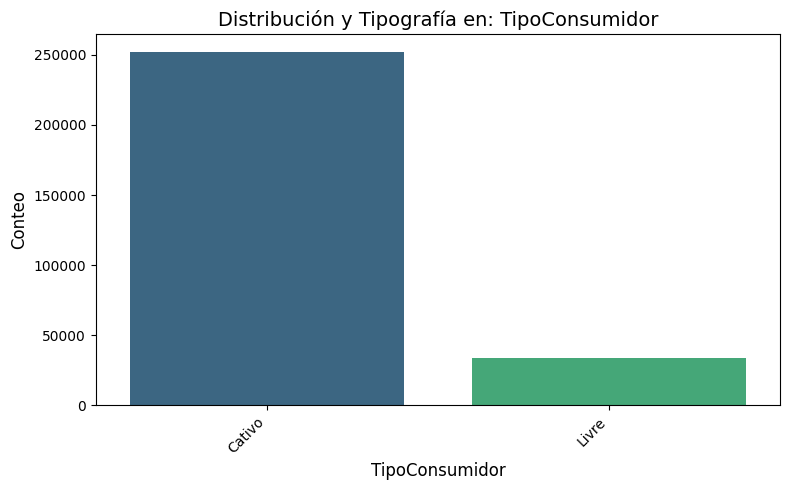

/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


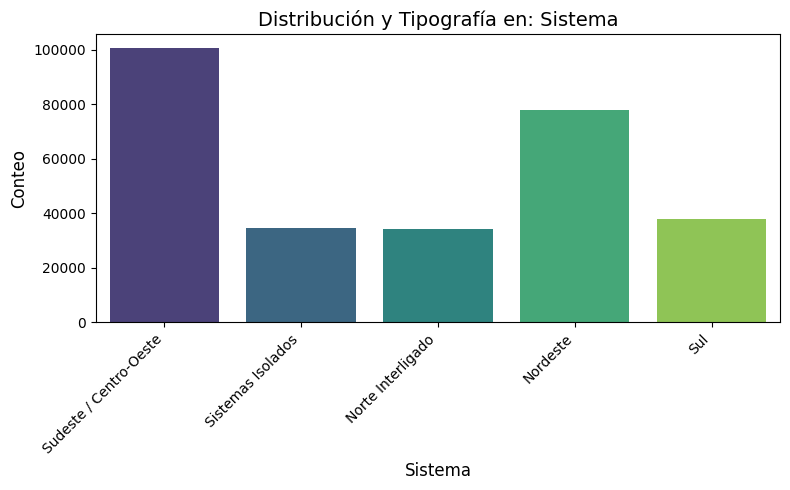

/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


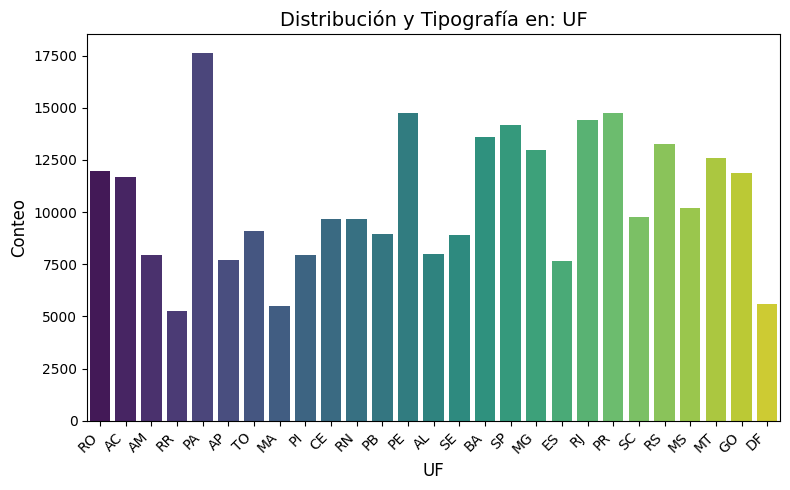

/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


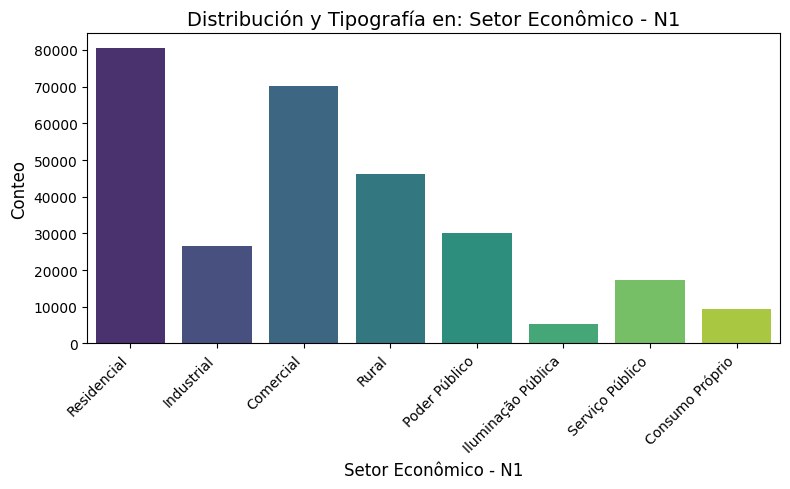

/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


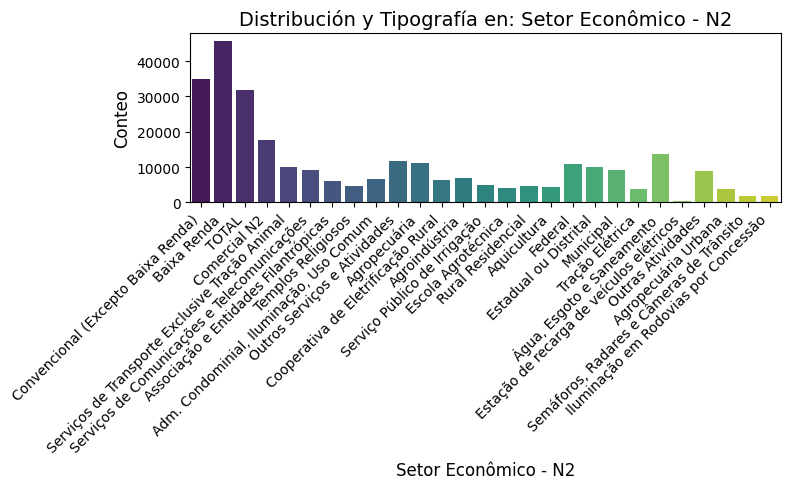

/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


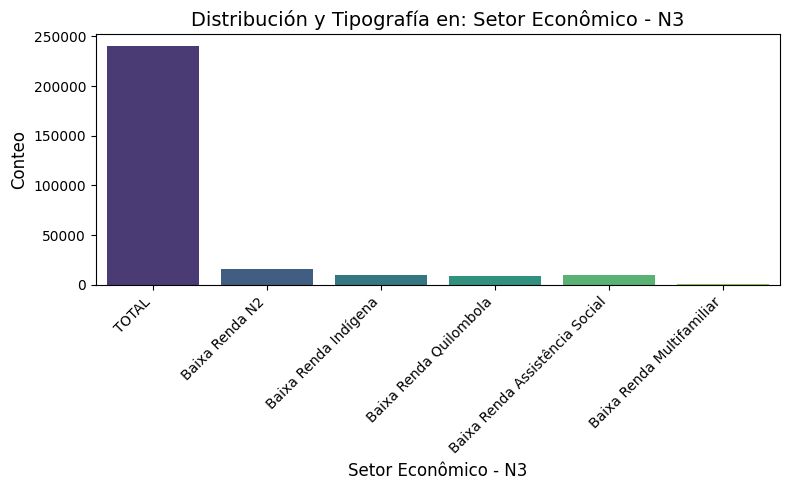

/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


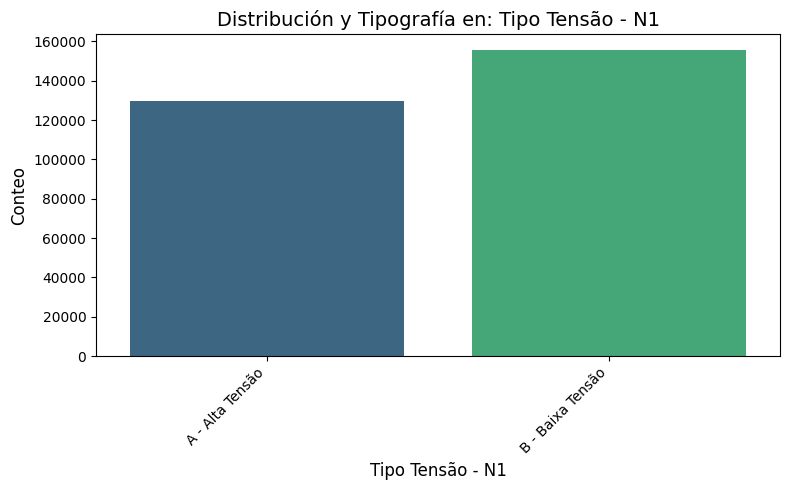

/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


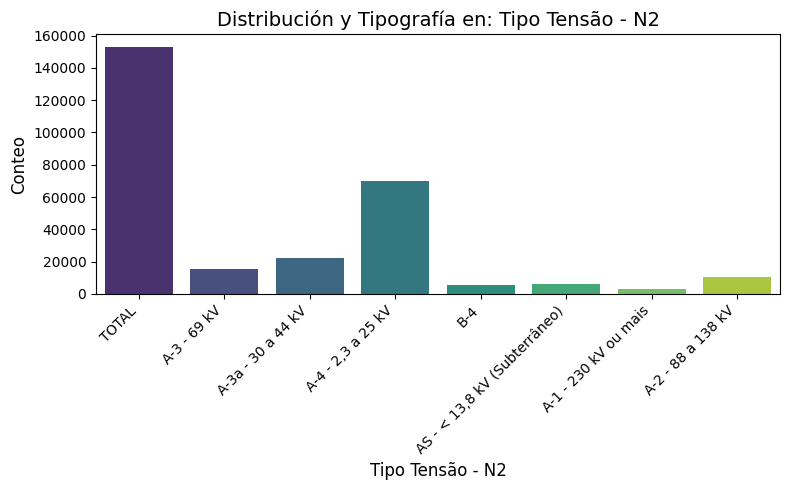

/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


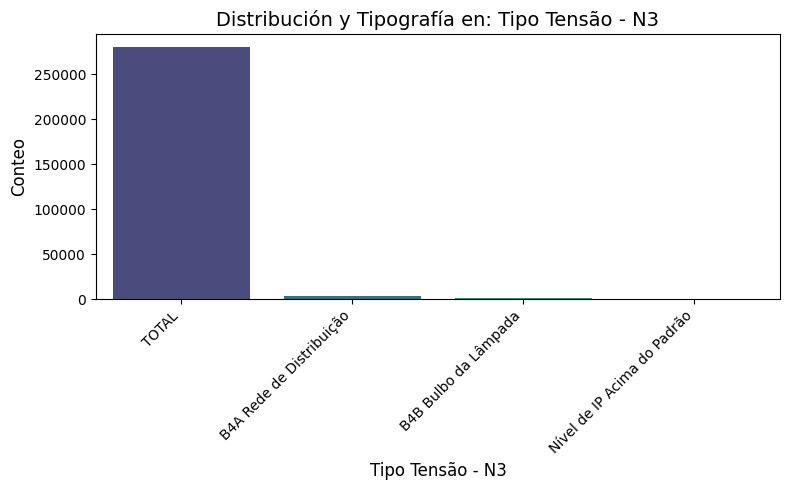

/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


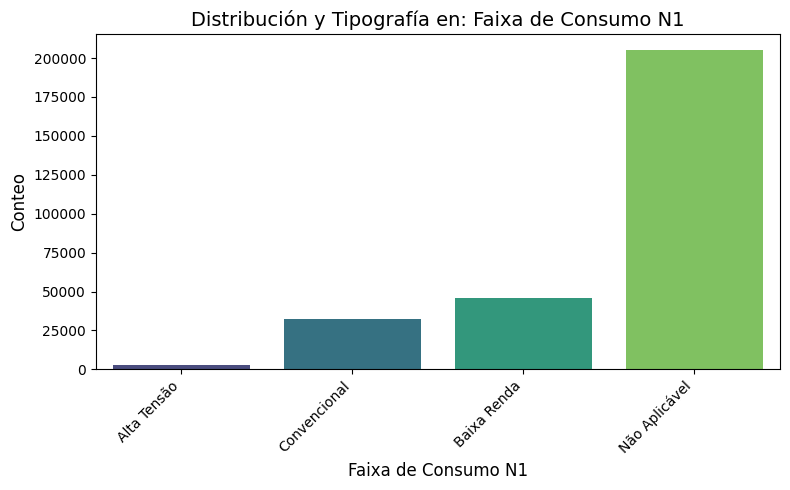

/tmp/ipykernel_5512/930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
/tmp/ipykernel_5512/930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


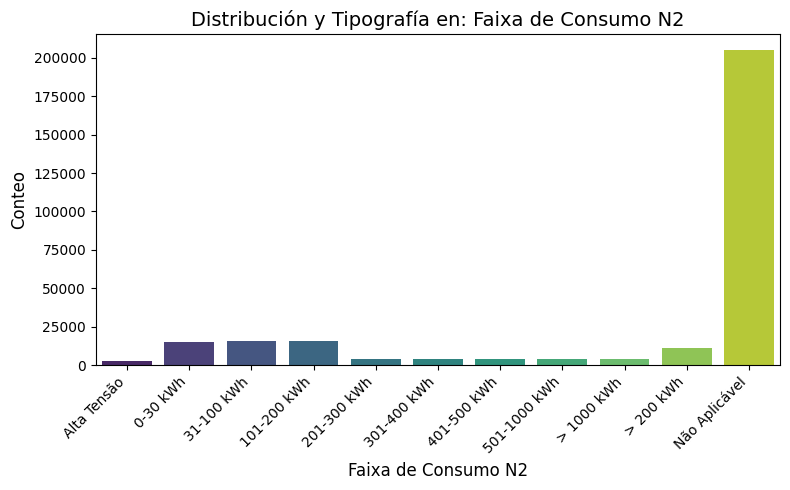

In [9]:
clean_01.verificar_errores_tipograficos()

In [10]:
clean_01.verificar_nulos()

🛑 Se encontraron datos faltantes en las siguientes columnas: 
              Cantidad Nulos  Porcentaje Nulos
Consumo                 9700               3.4
Consumidores            3988               1.4


In [11]:
clean_01.rellenar_nulos_cero()


In [12]:
clean_01.data_info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Data                  285499 non-null  datetime64[ns]
 1   TipoConsumidor        285499 non-null  object        
 2   Sistema               285499 non-null  object        
 3   UF                    285499 non-null  object        
 4   Setor Econômico - N1  285499 non-null  object        
 5   Setor Econômico - N2  285499 non-null  object        
 6   Setor Econômico - N3  285499 non-null  object        
 7   Tipo Tensão - N1      285499 non-null  object        
 8   Tipo Tensão - N2      285499 non-null  object        
 9   Tipo Tensão - N3      285499 non-null  object        
 10  Faixa de Consumo N1   285499 non-null  object        
 11  Faixa de Consumo N2   285499 non-null  object        
 12  Consumidores          285499 non-null  float64       
 13 

In [13]:
clean_01.verificar_valores_negativos()

--- Verificación de Valores Negativos ---
❌ ¡ALERTA! Se encontraron 59 valores negativos en la columna 'Consumidores'.
❌ ¡ALERTA! Se encontraron 635 valores negativos en la columna 'Consumo'.


In [14]:
clean_01.eliminar_negativos()

--- Eliminación de Valores Negativos ---
✅ Se eliminaron 675 filas con valores negativos.
El DataFrame ahora tiene 284824 filas.


In [15]:
clean_01.data_info()

<class 'pandas.core.frame.DataFrame'>
Index: 284824 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Data                  284824 non-null  datetime64[ns]
 1   TipoConsumidor        284824 non-null  object        
 2   Sistema               284824 non-null  object        
 3   UF                    284824 non-null  object        
 4   Setor Econômico - N1  284824 non-null  object        
 5   Setor Econômico - N2  284824 non-null  object        
 6   Setor Econômico - N3  284824 non-null  object        
 7   Tipo Tensão - N1      284824 non-null  object        
 8   Tipo Tensão - N2      284824 non-null  object        
 9   Tipo Tensão - N3      284824 non-null  object        
 10  Faixa de Consumo N1   284824 non-null  object        
 11  Faixa de Consumo N2   284824 non-null  object        
 12  Consumidores          284824 non-null  float64       
 13  Cons

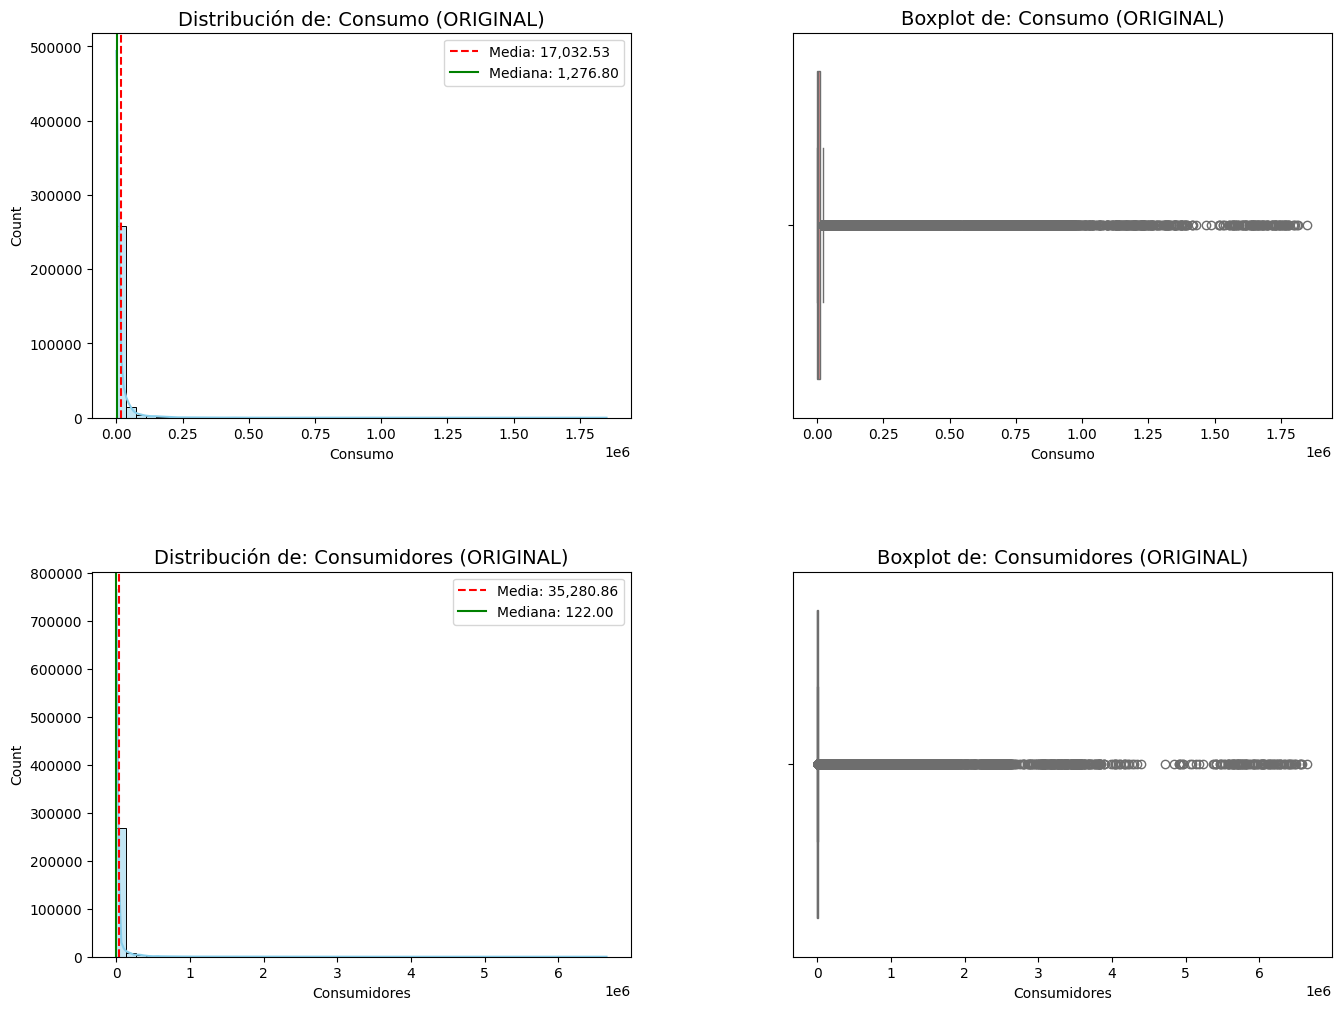

In [16]:
clean_01.verificar_outlier(log_scale=False)

In [17]:
clean_01.capping_outliers()

Iniciando deteccion y tratamiento de valores atipicos
-> En 'Consumo': 40844 valores atípicos limitados (Capping) al valor de 22385.00.
-> En 'Consumidores': 57035 valores atípicos limitados (Capping) al valor de 7513.00.


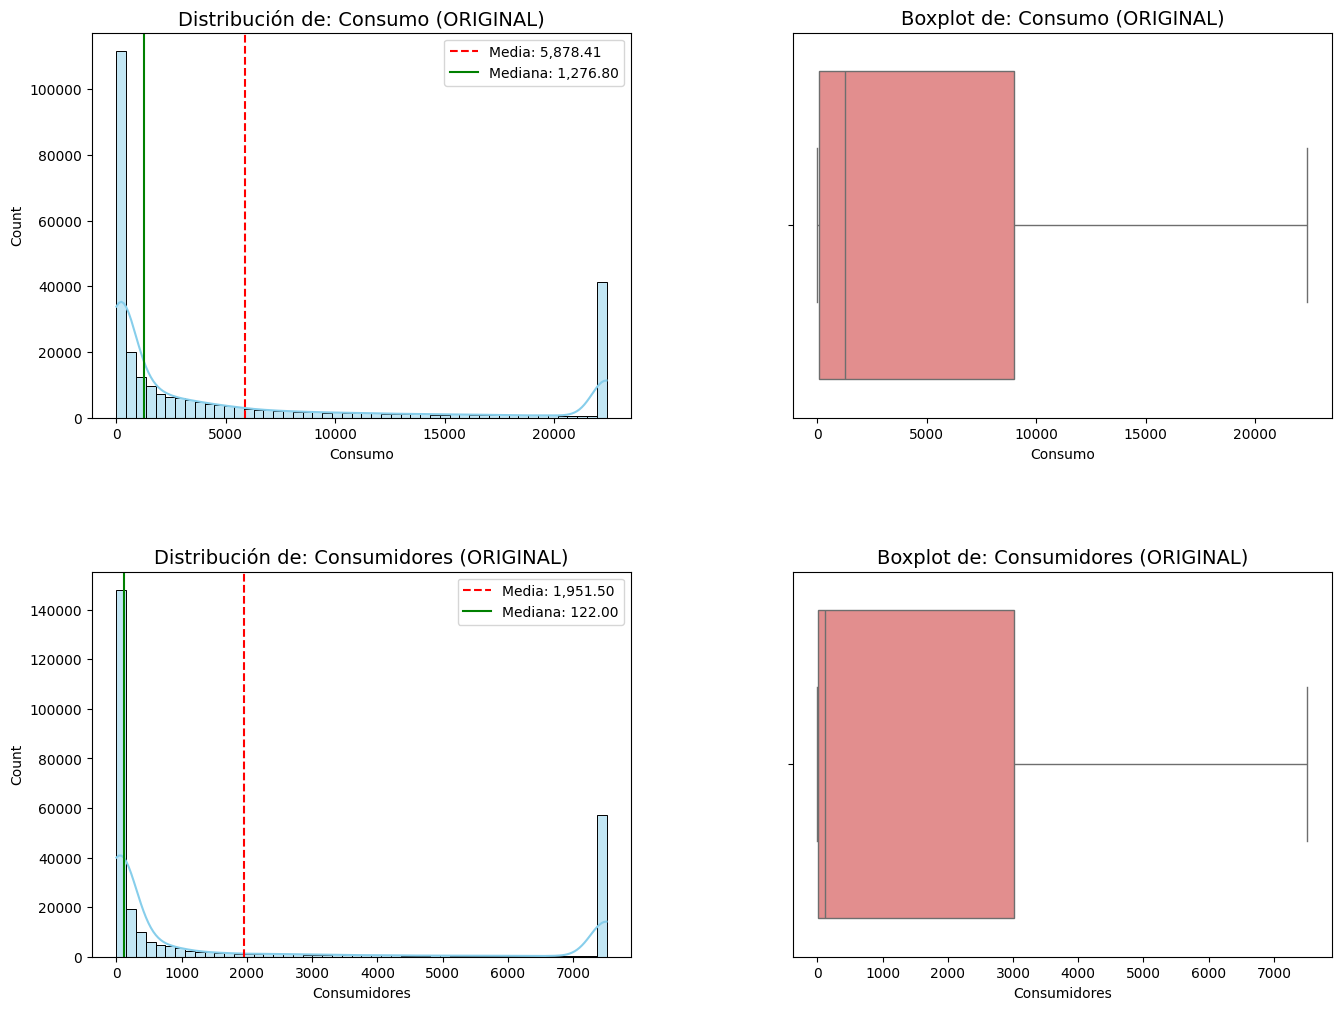

In [18]:
clean_01.verificar_outlier(log_scale=False)

In [19]:
clean_01.confirmar_capping()

22385.0


In [20]:
clean_01.transformar_logaritmica()

Aplicando Transformación Logarítmica a Consumo y Consumidores...
✅ Transformación completada. Nuevas columnas listas para el análisis.


In [21]:
clean_01.data_info()


<class 'pandas.core.frame.DataFrame'>
Index: 284824 entries, 0 to 285498
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Data                  284824 non-null  datetime64[ns]
 1   TipoConsumidor        284824 non-null  object        
 2   Sistema               284824 non-null  object        
 3   UF                    284824 non-null  object        
 4   Setor Econômico - N1  284824 non-null  object        
 5   Setor Econômico - N2  284824 non-null  object        
 6   Setor Econômico - N3  284824 non-null  object        
 7   Tipo Tensão - N1      284824 non-null  object        
 8   Tipo Tensão - N2      284824 non-null  object        
 9   Tipo Tensão - N3      284824 non-null  object        
 10  Faixa de Consumo N1   284824 non-null  object        
 11  Faixa de Consumo N2   284824 non-null  object        
 12  Consumidores          284824 non-null  float64       
 13  Cons

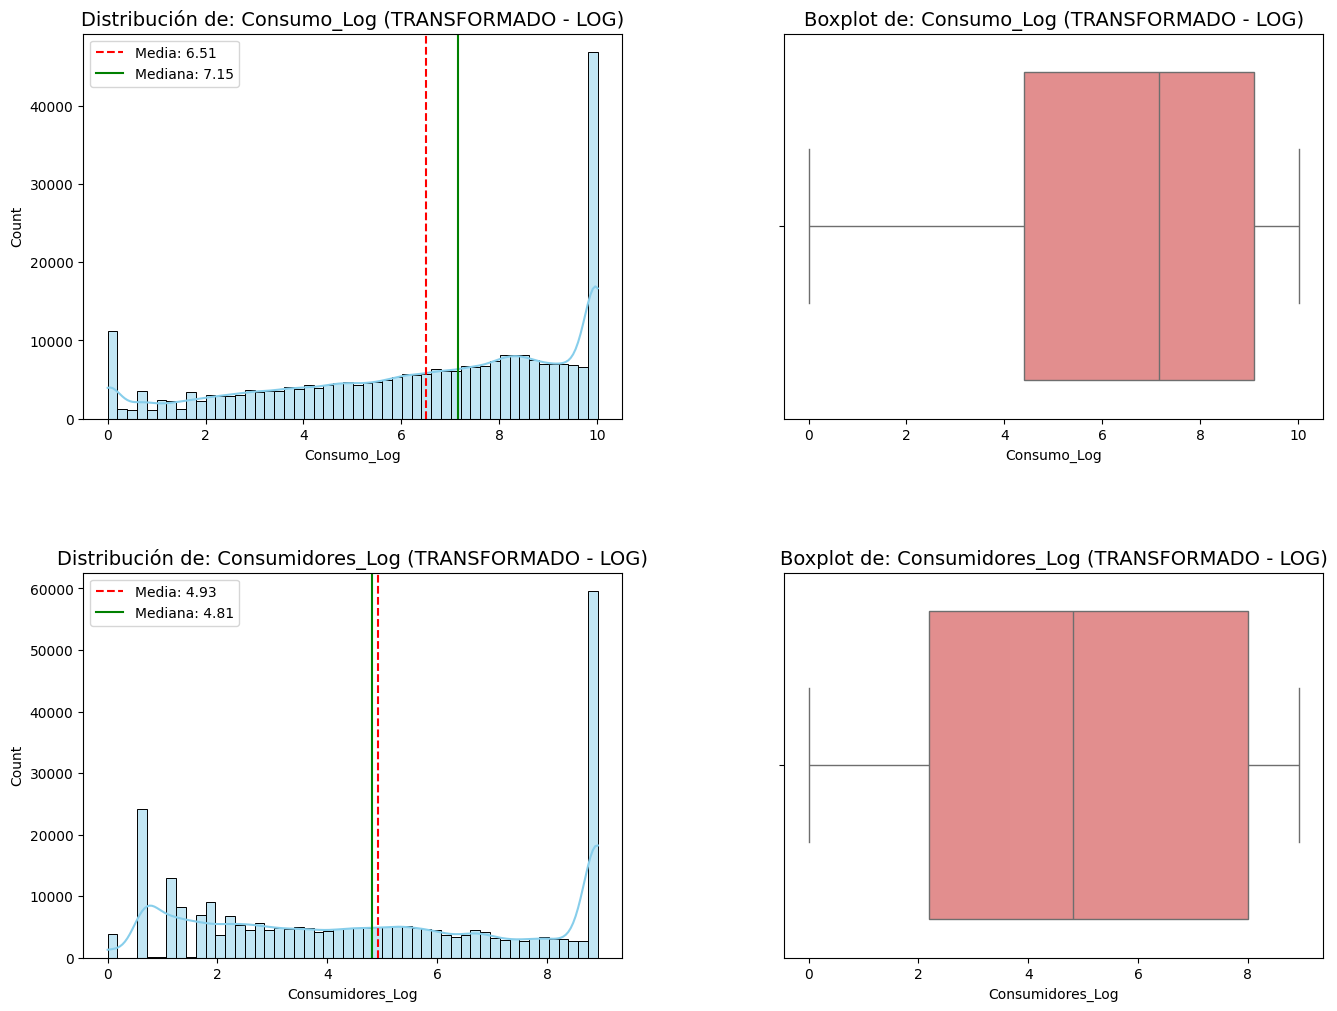

In [22]:
clean_01.verificar_outlier(log_scale=True)

In [ ]:
import calendar

class EnergyAnalyzer:
    def __init__(self, df_cleaned: pd.DataFrame):
        """Inicializa el analizador con el DataFrame ya limpio y transformado."""
        self.df = df_cleaned
        print("Analizador de Energía inicializado con DataFrame listo.")
        
    # -------------------------------------------------------------------------
    # 1. Análisis de Temporalidad (Tendencias y Estacionalidad): grafica el consumo total mes a mes a lo largo de los años
    # -------------------------------------------------------------------------
    def analizar_temporalidad(self):
        """Calcula y grafica la tendencia mensual del consumo logarítmico total."""
        print("\n--- 1. Análisis de Tendencia Mensual ---")
        
        # Agrupar por mes/año y sumar el consumo logarítmico.
        # Esto mitiga el impacto de los outliers y muestra la tendencia real.
        '''1. set.index('Data'): convierte la columna de fechas y horas (Data) del dataframe self.df en el indice del dataframe, 
              para poder usar la funcionalidad de remuestreo (resempling) de Pandas, es un requisito que la columna de fechas sea el indice.
           2. resample('M'): agrupa el dataframe por periodos de tiempo
              Argumento 'M': significa "Month End Frequency (Frecuencia de fin de mes), que crea un grupo de filas para cada mes presente en los datos.)
           3. ['Consumo_Log']: selecciona la columna Consumo_Log para realizar la agregacion.
           4. sum(): aplica la suma a todos los valores de la columna Consumo_Log dentro de cada grupo mensual.
           5. reset_index(): convierte el indice de fecha de nuevo en una columna regular del dataframe, para graficar la serie de tiempo con Seaborn
           '''
        df_tendencia = self.df.set_index('Data').resample('M')['Consumo_Log'].sum().reset_index() # devuelve un dataframe (df_tendencia) que contiene una fila
                                                                                                  # por cada mes/ano y el consumo total agregado para ese periodo
        
        plt.figure(figsize=(12, 6))
        sns.lineplot(x='Data', y='Consumo_Log', data=df_tendencia, linewidth=2, color='darkorange')
        plt.title('Tendencia del Consumo Total (Escala Logarítmica) Mensual', fontsize=16)
        plt.xlabel('Fecha', fontsize=12)
        plt.ylabel('Consumo Total (Log)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    # -------------------------------------------------------------------------
    # 2. preparar_datos_estacionalidad: prepara la segmentacion delos diferentes grupos determinados (ej: 'Residencial'),
    # para ver como el consumo de grupos determinados , cambia mes a mes a lo largo de los años.
    # -------------------------------------------------------------------------
    def _preparar_datos_estacionalidad(self, df, filtro_columna, filtro_valor):
        """Función auxiliar para preparar los datos de estacionalidad.
           Patrones de estacionalidad: se refiere a las fluctuaciones en una serie de tiempo que
           ocurren con regularidad y se repiten en periodos fijos de tiempo, clave para entender como
           el consumo varia segun el momento del ano.
        """

        # segmentar los datos por categoria espesifica antes de realizar el analisis de estacionalidad.
        # Objetivo: seleccionar un subconjunto de filas del dataframe basandose en una condicion espesifica,
        # y luego crear una copia indipendiente de esos datos.

        # Devuelve una Serie booleanda (una columna de True o False)
        df_estacionalidad = df[df[filtro_columna] == filtro_valor].copy()
        
        if df_estacionalidad.empty:
            return None, "No hay datos", 0

        # Aislar y almacenar el año de la columna fechas en una nueva columna.
        # .dt es un metodo de pandas (datetime) que permite acceder a componentes espesificos de la fecha   
        df_estacionalidad['Año'] = df_estacionalidad['Data'].dt.year
        df_estacionalidad['Mes_Numero'] = df_estacionalidad['Data'].dt.month
        
        # agrupar el consumo logaritmico por cada combinacion unica de Año y mes, y luego sumando esos valores.
        # .reset_index() separa el index de año y mes y lo almacena en las nuevas columnas Año, Mes_Numero
        df_agrupado = df_estacionalidad.groupby(['Año', 'Mes_Numero'])['Consumo_Log'].sum().reset_index()

        # Convertir los numeros del mes (1,2,3...) en sus nombres abreviados (Ene, Feb, Mar.....)
        df_agrupado['Mes_Nombre'] = df_agrupado['Mes_Numero'].apply(lambda x: calendar.month_abbr[x])
        
        # Devuelve el df_agrupado que contiene (Año, Mes, Consumo_log), la etiqueta de filtrado filtro_valor y calcula y devuelve 
        # la suma total del consumo logaritmico para el segmento que se quiere analizar.
        return df_agrupado, filtro_valor, df_estacionalidad['Consumo_Log'].sum()

    # -------------------------------------------------------------------------
    # 3. Comparación de Estacionalidad: Alta vs. Baja Tensión
    # -------------------------------------------------------------------------
    def comparar_estacionalidad_tension(self, columna_tension='Tipo Tensão - N1'):
        """
        Compara la estacionalidad del consumo (Log) de Alta Tensión vs. Baja Tensión.
        """
        print("\n--- Comparación de Estacionalidad: Alta vs. Baja Tensión ---")
        
        tensiones = ['A - Alta Tensão', 'B - Baixa Tensão']
        
        fig, axes = plt.subplots(
            nrows=1, 
            ncols=2, 
            figsize=(18, 7) # Figura ancha para 2 gráficos lado a lado
        )
        plt.subplots_adjust(wspace=0.3)

        for i, tension in enumerate(tensiones):
            
            # Usar la función auxiliar para preparar los datos de cada segmento
            df_agrupado, valor, consumo_total = self._preparar_datos_estacionalidad(
                self.df, columna_tension, tension
            )

            if df_agrupado is None:
                axes[i].set_title(f"Sin datos para {tension}", fontsize=16)
                continue
                
            # Graficar
            sns.lineplot(
                data=df_agrupado,
                x='Mes_Numero',
                y='Consumo_Log',
                hue='Año',
                palette='tab10',
                linewidth=2,
                ax=axes[i]
            )
            
            # Configuración de Ejes y Títulos
            # Mostrar las etiquetas en el eje x de los nombres abreviados de los meses en el orden correcto.
            axes[i].set_xticks(
                df_agrupado['Mes_Numero'].unique(), 
                df_agrupado.sort_values('Mes_Numero')['Mes_Nombre'].unique() # el metodo unique elimina cualquier duplicado en una Serie de pandas.
            )
            axes[i].set_title(f'Estacionalidad Mensual: {tension}', fontsize=16)
            axes[i].set_xlabel('Mes', fontsize=12)
            axes[i].set_ylabel('Consumo Total Acumulado (Log)', fontsize=12)
            axes[i].legend(title='Año', loc='upper right')
            axes[i].grid(True, linestyle='--', alpha=0.6)

        plt.suptitle('Análisis Comparativo de Estacionalidad (Consumo Log)', fontsize=20, y=1.02)
        plt.show()



    # -------------------------------------------------------------------------
    # 3. Análisis Geográfico (Top UFs/Estados por Consumo)
    # -------------------------------------------------------------------------
    def analizar_geografia(self, top_n=10):
        """Identifica los estados (UF) con mayor consumo total."""
        print(f"\n--- 2. Análisis Geográfico (Top {top_n} UFs por Consumo Absoluto) ---")
        
        # Usamos Consumo original para reportar el valor absoluto de negocio
        df_geo = self.df.groupby('UF')['Consumo'].sum().sort_values(ascending=False)
        
        num_ufs = len(df_geo)
        plt.figure(figsize=(num_ufs * 0.5, 6))
        
        # Gráfico de barras con anotaciones para mejor lectura
        ax = df_geo.plot(kind='bar', color=sns.color_palette("viridis"))
        
        plt.title(f'Top {top_n} UFs (Estados) por Consumo Total Acumulado', fontsize=16)
        plt.xlabel('UF (Estado)', fontsize=12)
        plt.ylabel('Consumo Total (Millones)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.ticklabel_format(style='plain', axis='y') # Evita notación científica en Y
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.show()

    # -------------------------------------------------------------------------
    # 4. Análisis del Mix de Clientes (Consumo por Sector N1)
    # -------------------------------------------------------------------------
    def analizar_mix_clientes(self):
        """
        Analiza qué sector (N1) domina el mercado en términos de Consumo Total.
        """
        print("\n--- 4. Análisis del Mix de Clientes por Sector Económico (N1) ---")
        
        # 1. Agregación de datos por Consumo Total
        df_mix = self.df.groupby('Setor Econômico - N1')['Consumo'].sum().reset_index()

        # Ordenar por el mayor Consumo para la visualización
        df_mix = df_mix.sort_values(by='Consumo', ascending=False)
        
        # 2. Visualización
        plt.figure(figsize=(10, 6))
        
        sns.barplot(
            x='Consumo', 
            y='Setor Econômico - N1', 
            data=df_mix, 
            palette=sns.color_palette("plasma", len(df_mix))
        )
        
        plt.title('Dominancia de Consumo Total por Sector Económico (N1)', fontsize=16)
        plt.xlabel('Consumo Total Acumulado (Escala Original)', fontsize=12)
        plt.ylabel('Sector Económico (N1)', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.ticklabel_format(style='plain', axis='x') # Evita notación científica
        plt.show()
        
        # 3. Reporte del Dominio
        dominante = df_mix.iloc[0]['Setor Econômico - N1']
        print(f"\n💡 El sector dominante en el mercado de consumo es: {dominante}")
        print("A continuación, debemos adaptar el análisis temporal exclusivamente para este sector.")

    # -------------------------------------------------------------------------
    # 5. Análisis de Proporción Consumo vs. Consumidores (Tensión)
    # -------------------------------------------------------------------------
    def analizar_proporcion_tension(self, columna_tension='Tipo Tensão - N1'): # <-- Columna por defecto
        """
        Analiza si el mayor consumo proviene de pocos clientes de alta tensión.
        Utiliza la columna 'Tipo Tensão - N1' por defecto.
        """
        print(f"\n--- 5. Análisis de Concentración del Mercado por Tensión: {columna_tension} ---")

        if columna_tension not in self.df.columns:
            # Esta validación sigue siendo útil si se llama con otra columna
            print(f"❌ Error: La columna '{columna_tension}' no se encuentra en el DataFrame.")
            return

        # 1. Agrupar por la columna de tensión y calcular los totales
        df_tension = self.df.groupby(columna_tension).agg(
            Consumo_Total=('Consumo', 'sum'),
            Consumidores_Total=('Consumidores', 'sum')
        ).reset_index()

        # 2. Calcular la proporción (%) de cada métrica sobre el total general
        consumo_total_gral = df_tension['Consumo_Total'].sum()
        consumidores_total_gral = df_tension['Consumidores_Total'].sum()

        df_tension['Consumo_Prop'] = (df_tension['Consumo_Total'] / consumo_total_gral) * 100
        df_tension['Consumidores_Prop'] = (df_tension['Consumidores_Total'] / consumidores_total_gral) * 100

        # 3. Preparar los datos para la visualización
        df_plot = df_tension.melt(
            id_vars=[columna_tension], 
            value_vars=['Consumo_Prop', 'Consumidores_Prop'],
            var_name='Métrica', 
            value_name='Proporción (%)'
        )
        
        # 4. Graficar la concentración
        plt.figure(figsize=(10, 6))
        
        sns.barplot(
            x='Proporción (%)', 
            y=columna_tension, 
            hue='Métrica', 
            data=df_plot,
            palette={'Consumo_Prop': 'darkred', 'Consumidores_Prop': 'darkblue'}
        )
        
        plt.title(f'Proporción de Consumo vs. Consumidores por {columna_tension}', fontsize=16)
        plt.xlabel('Proporción del Total del Mercado (%)', fontsize=12)
        plt.ylabel(columna_tension, fontsize=12)
        plt.legend(title='Métrica')
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.show()
        
    # -------------------------------------------------------------------------
    # 3. Análisis Sectorial (Promedio de Consumo por Sector)
    # -------------------------------------------------------------------------
    def analizar_sector_consumo(self):
        """Identifica los sectores económicos más importantes por consumo logarítmico promedio."""
        print("\n--- 3. Análisis Sectorial por Consumo Promedio (Log) ---")
        
        # Usar Consumo_Log promedio para una distribución más justa del peso (menos sensible a outliers)
        df_sector = self.df.groupby('Setor Econômico - N1')['Consumo_Log'].mean().sort_values(ascending=False)
        
        plt.figure(figsize=(12, 8))
        ax = df_sector.plot(kind='barh', color='teal') # Gráfico horizontal para mejor lectura
        
        plt.title('Ranking de Consumo Promedio (Log) por Sector Económico', fontsize=16)
        plt.xlabel('Consumo Promedio (Log)', fontsize=12)
        plt.ylabel('Sector Económico', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.show()

    
    
    # -------------------------------------------------------------------------
    # 9. Tendencia Anual del Consumo Industrial por Región (UF)
    # -------------------------------------------------------------------------
    def analizar_tendencia_industrial_regional(self, setor_n1='Industrial'):
        """
        Genera un gráfico que muestra la variación del Consumo Total (Log) 
        del sector industrial, comparando las regiones (UF) a lo largo de los años.
        
        :param setor_n1: Nombre exacto del sector industrial en N1 (por defecto 'INDUSTRIA').
        """
        
        print(f"\n--- 9. Tendencia Anual del Consumo Total de {setor_n1} por Región ---")

        # 1. Validación y Filtrado Inicial por Sector N1 (Industria)
        df_industrial = self.df.copy()

        if setor_n1 not in df_industrial['Setor Econômico - N1'].unique():
             print(f"❌ Error: El sector N1 '{setor_n1}' no se encontró. Revise el nombre exacto en su DataFrame.")
             return
        
        df_industrial = df_industrial[
            df_industrial['Setor Econômico - N1'] == setor_n1
        ]
        
        if df_industrial.empty:
            print(f"⚠️ No se encontraron datos para el sector: {setor_n1}.")
            return
            
        # 2. Preparación temporal y agrupación
        df_industrial['Año'] = df_industrial['Data'].dt.year
        
        # Agrupación clave: por Año y UF, sumando el Consumo_Log
        df_agrupado = df_industrial.groupby(['Año', 'UF'])['Consumo_Log'].sum().reset_index()
        
        # 3. Graficar con FacetGrid (simulando relplot para control)
        plt.figure(figsize=(14, 8))
        
        # Usamos lineplot para conectar los años y scatterplot para los puntos
        sns.lineplot(
            data=df_agrupado,
            x='UF', 
            y='Consumo_Log', 
            hue='Año', 
            palette='viridis', # Usamos una paleta con variación de color por Año
            marker='o',        # Añadimos marcadores para ver los puntos de dato
            linewidth=2
        )
        
        # 4. Configuración de Ejes y Títulos
        plt.title(f'Tendencia del Consumo Industrial Total (Log) por UF y Año', fontsize=18)
        plt.xlabel('Región (UF)', fontsize=14)
        plt.ylabel('Consumo Total Acumulado (Log)', fontsize=14)
        
        # Posicionamos la leyenda
        plt.legend(title='Año', bbox_to_anchor=(1.0, 1), loc='upper left')
        
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 10. Uso de Tensión (Alta/Baja) por Sector Económico
    # -------------------------------------------------------------------------
    def analizar_tension_por_sector(self, columna_sector='Setor Econômico - N1', columna_tension='Tipo Tensão - N1'):
        """
        Grafica el número total de consumidores para cada Sector Económico (N1), 
        diferenciando por el tipo de Tensión (N1).
        """
        
        print(f"\n--- 10. Consumidores por Sector Económico vs. Tipo de Tensión ---")

        # 1. Agrupación de datos: Consumidores por Sector y Tensión
        df_agrupado = self.df.groupby([columna_sector, columna_tension])['Consumidores'].sum().reset_index()
        
        # 2. Reorganizar para ordenar las barras por Consumidores totales (opcional, mejora la lectura)
        orden_sectores = df_agrupado.groupby(columna_sector)['Consumidores'].sum().sort_values(ascending=False).index
        
        # 3. Graficar
        plt.figure(figsize=(14, 8))
        
        sns.barplot(
            data=df_agrupado,
            x='Consumidores', 
            y=columna_sector, 
            hue=columna_tension, 
            order=orden_sectores,
            palette={'A - Alta Tensão': 'darkred', 'B - Baixa Tensão': 'darkblue'} # Paleta clara para distinción
        )

        # 4. Configuración de Ejes y Títulos
        plt.title(f'Distribución de Consumidores por Sector Económico y Tipo de Tensión', fontsize=18)
        plt.xlabel('Número Total de Consumidores', fontsize=14)
        plt.ylabel(columna_sector, fontsize=14)
        
        plt.ticklabel_format(style='plain', axis='x') # Evita notación científica en el Eje X
        
        plt.legend(title=columna_tension, loc='lower right')
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 11. Proporción de Clientes por Rango de Consumo (Faixa de Consumo)
    # -------------------------------------------------------------------------
    def analizar_segmentacion_clientes(self, columna_rango='Faixa de Consumo'):
        """
        Grafica la proporción del número total de consumidores que cae en cada
        rango de consumo (Faixa de Consumo).
        """
        
        print(f"\n--- 11. Proporción de Consumidores por Rango de Consumo ({columna_rango}) ---")

        # 1. Agrupar el número total de consumidores por rango
        df_segmento = self.df.groupby(columna_rango)['Consumidores'].sum().reset_index()

        # 2. Calcular el porcentaje de consumidores en cada rango
        total_consumidores = df_segmento['Consumidores'].sum()
        df_segmento['Proporcion (%)'] = (df_segmento['Consumidores'] / total_consumidores) * 100
        
        # 3. Ordenar los rangos si es posible (asumiendo que son categóricos y ordenados)
        # Esto requiere que los rangos estén en un orden lógico, si no, se ordenará alfabéticamente.
        # En Seaborn, un gráfico de pastel o barras ordenadas funciona bien.
        df_segmento = df_segmento.sort_values(by='Proporcion (%)', ascending=False)
        
        # 4. Graficar (Gráfico de barras para mejor lectura de valores bajos)
        plt.figure(figsize=(10, 8))
        ax = sns.barplot(
            data=df_segmento,
            x='Proporcion (%)', 
            y=columna_rango, 
            palette='Reds_d' # Paleta que destaca los rangos superiores (con mayor proporción)
        )
        
        plt.title('Distribución Porcentual de Consumidores por Rango de Consumo', fontsize=16)
        plt.xlabel('Proporción del Total de Consumidores (%)', fontsize=12)
        plt.ylabel('Rango de Consumo', fontsize=12)
        
        # Opcional: Anotar los valores para los rangos más pequeños
        for p in ax.patches:
            width = p.get_width()
            plt.text(width + 1, p.get_y() + p.get_height()/2. + 0.1,
                     '{:1.1f}%'.format(width),
                     ha="left", fontsize=10)
        
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 12. Dinámica de Consumidores: Migración entre Rangos por Año
    # -------------------------------------------------------------------------
    def analizar_dinamica_crecimiento(self, columna_rango='Faixa de Consumo N2'):
        """
        Analiza la migración de consumidores entre rangos a lo largo de los años.
        El crecimiento general puede deberse a: 
        1) Clientes en rangos bajos se mueven a medios. 
        2) Clientes grandes consumen más.
        """
        
        print(f"\n--- 12. Dinámica de Crecimiento: Evolución de Consumidores por Rango ({columna_rango}) ---")

        # 1. Preparación temporal y agrupación
        df_dinamica = self.df.copy()
        df_dinamica['Año'] = df_dinamica['Data'].dt.year
        
        # Agrupación clave: por Año y Rango, sumando el número de Consumidores
        df_agrupado = df_dinamica.groupby(['Año', columna_rango])['Consumidores'].sum().reset_index()
        
        # 2. Graficar: Usaremos un gráfico de líneas para mostrar la evolución por rango
        plt.figure(figsize=(14, 8))
        
        sns.lineplot(
            data=df_agrupado,
            x='Año', 
            y='Consumidores', 
            hue=columna_rango, 
            palette='tab20', # Usar una paleta diversa para distinguir los rangos
            marker='o',
            linewidth=2
        )
        
        # 3. Configuración de Ejes y Títulos
        plt.title(f'Evolución Anual del Número de Consumidores por Rango de Consumo', fontsize=18)
        plt.xlabel('Año', fontsize=14)
        plt.ylabel('Número Total de Consumidores', fontsize=14)
        
        # Asegurar que el eje X muestre los años como números enteros
        plt.xticks(df_agrupado['Año'].unique())
        
        plt.legend(title=columna_rango, bbox_to_anchor=(1.0, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

Analizador de Energía inicializado con DataFrame listo.

--- 1. Análisis de Tendencia Mensual ---


/tmp/ipykernel_5512/114422885.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_tendencia = self.df.set_index('Data').resample('M')['Consumo_Log'].sum().reset_index() # devuelve un dataframe (df_tendencia) que contiene una fila


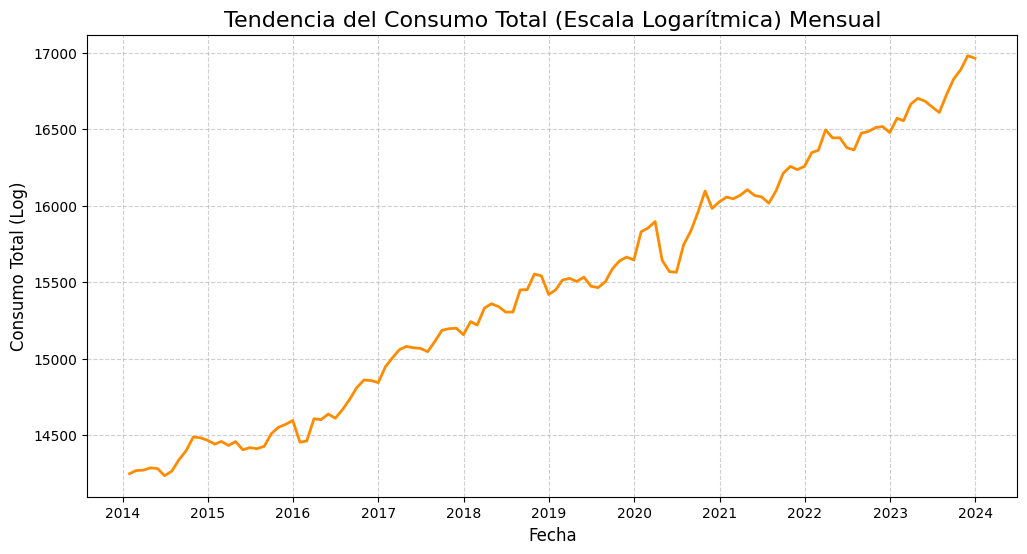


--- Comparación de Estacionalidad: Alta vs. Baja Tensión ---


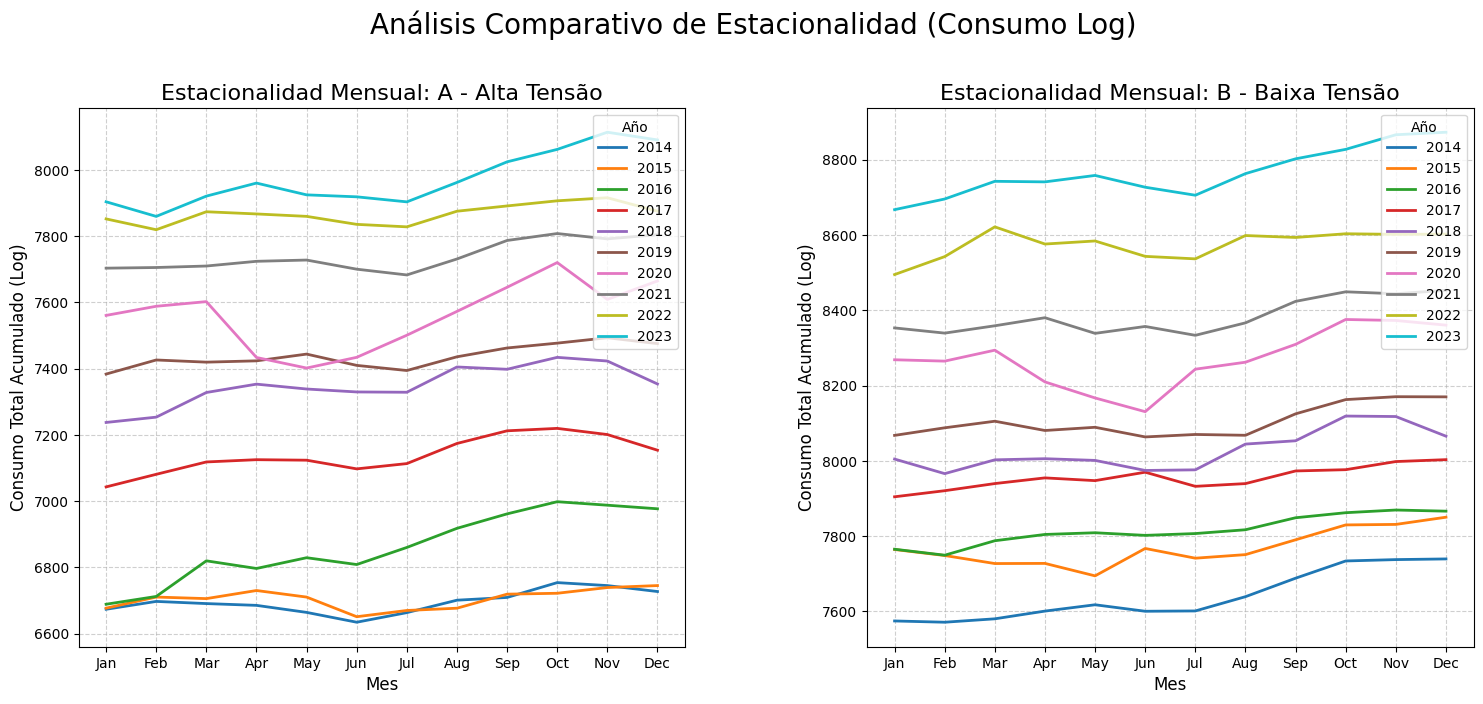


--- 2. Análisis Geográfico (Top 10 UFs por Consumo Absoluto) ---


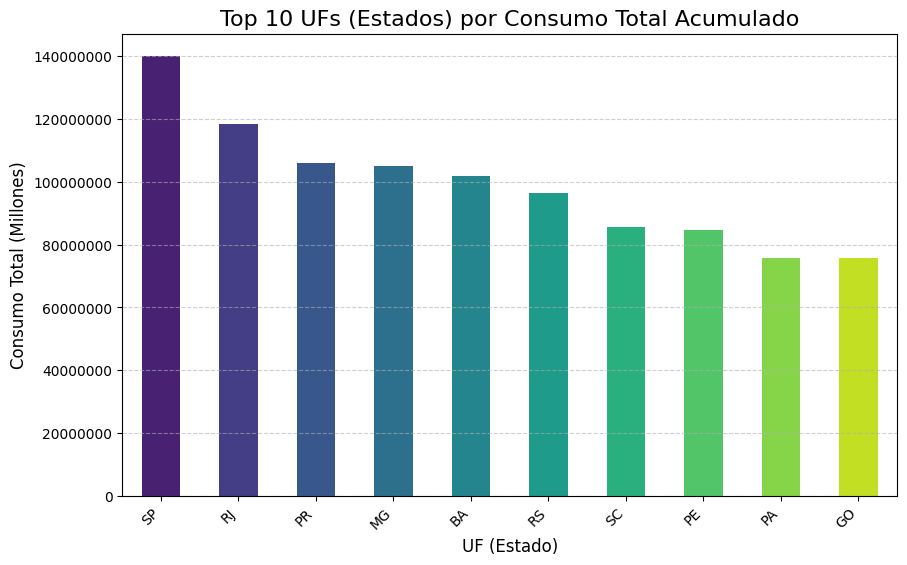


--- 4. Análisis del Mix de Clientes por Sector Económico (N1) ---


/tmp/ipykernel_5512/114422885.py:172: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


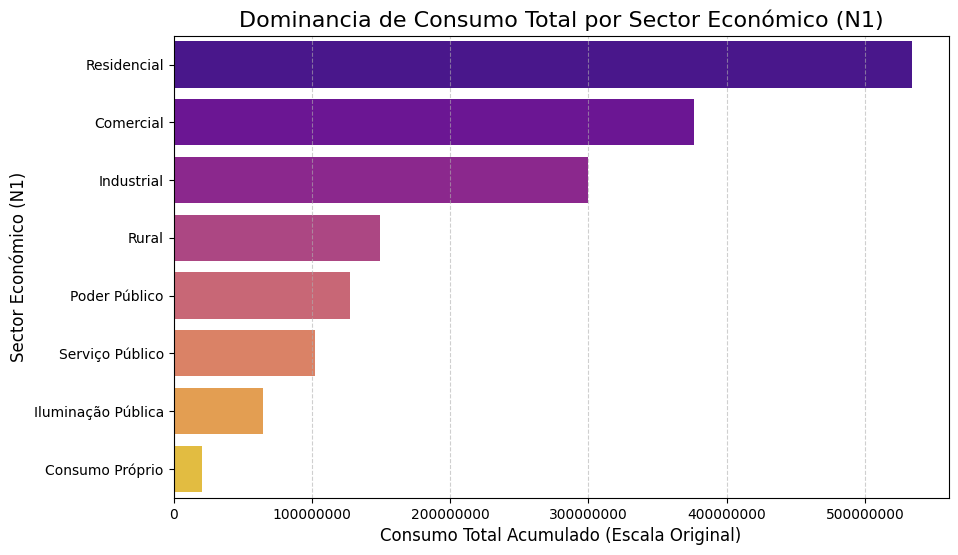


💡 El sector dominante en el mercado de consumo es: Residencial
A continuación, debemos adaptar el análisis temporal exclusivamente para este sector.

--- 5. Análisis de Concentración del Mercado por Tensión: Tipo Tensão - N1 ---


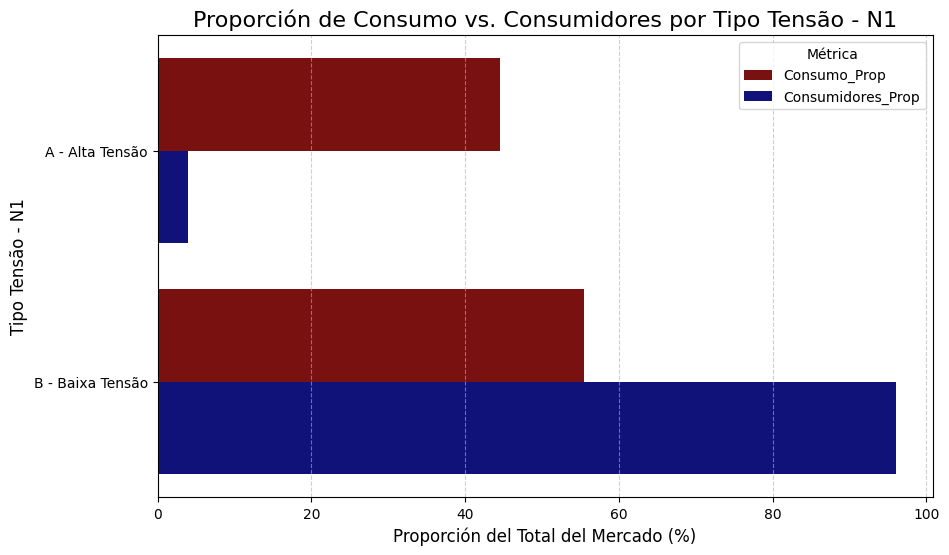


--- 3. Análisis Sectorial por Consumo Promedio (Log) ---


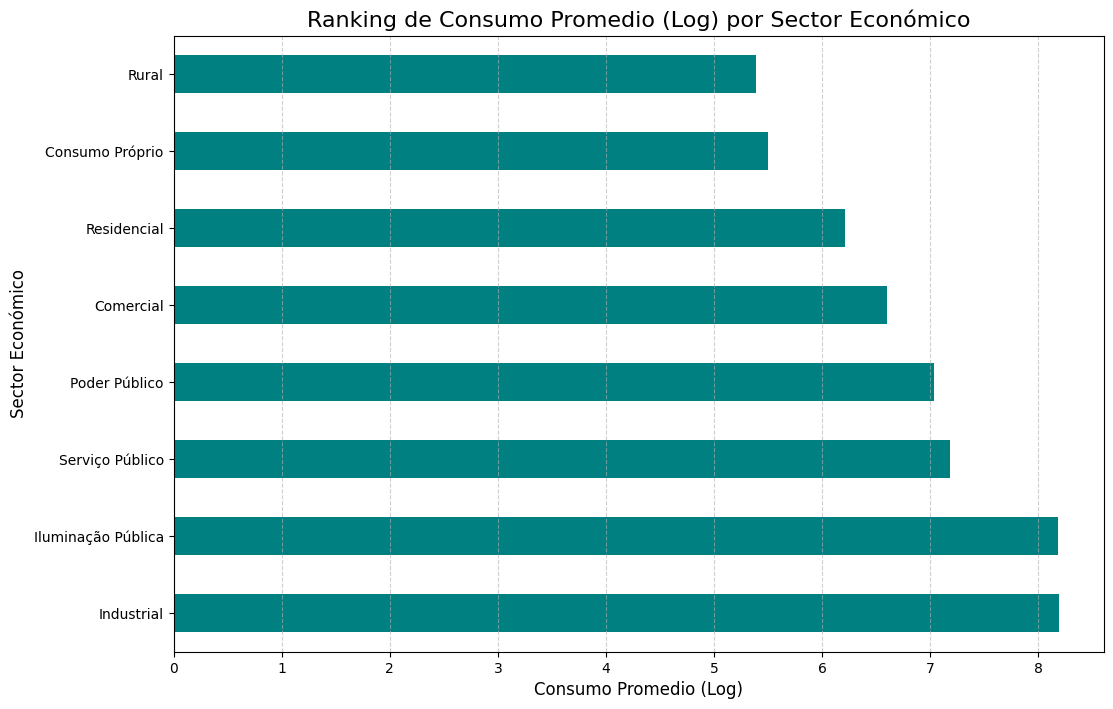


--- 9. Tendencia Anual del Consumo Total de Industrial por Región ---


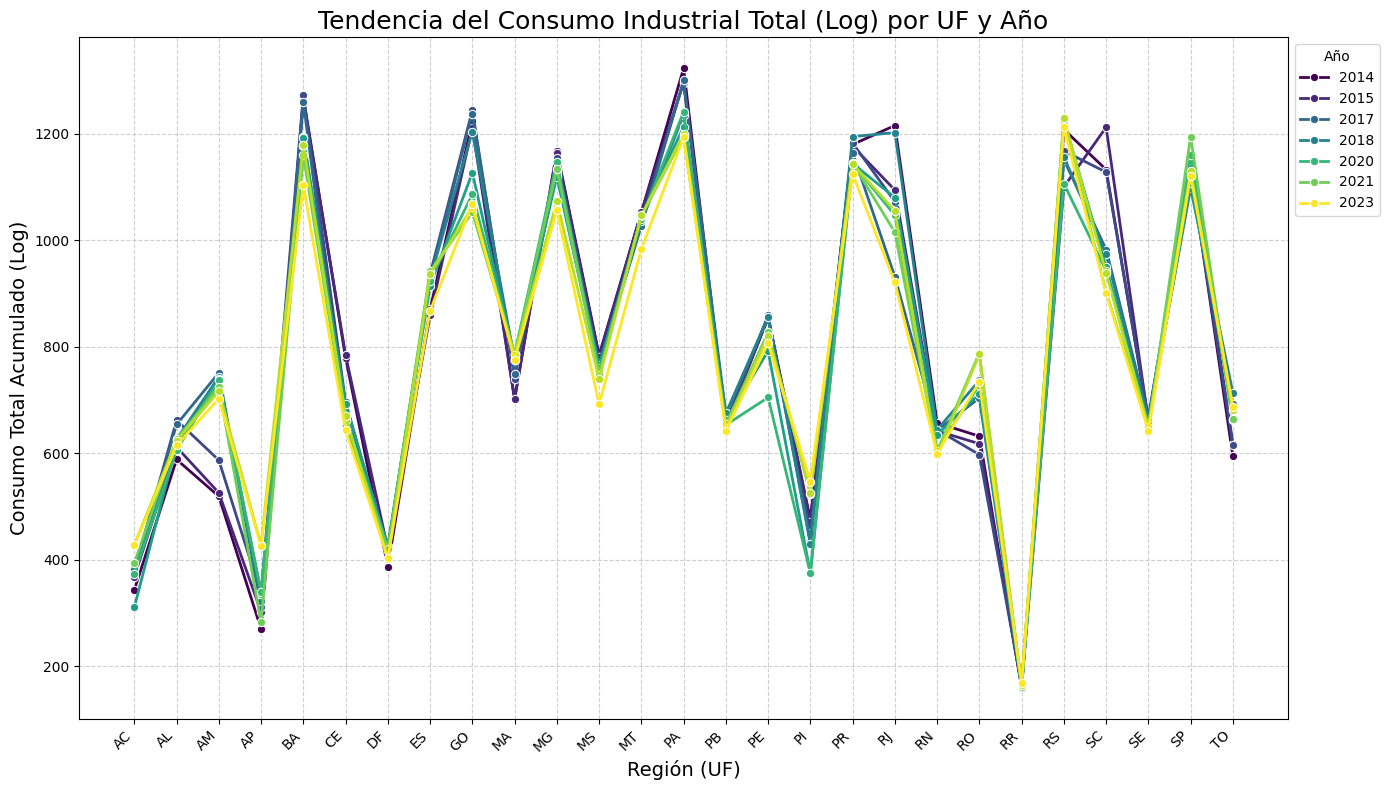


--- 10. Consumidores por Sector Económico vs. Tipo de Tensión ---


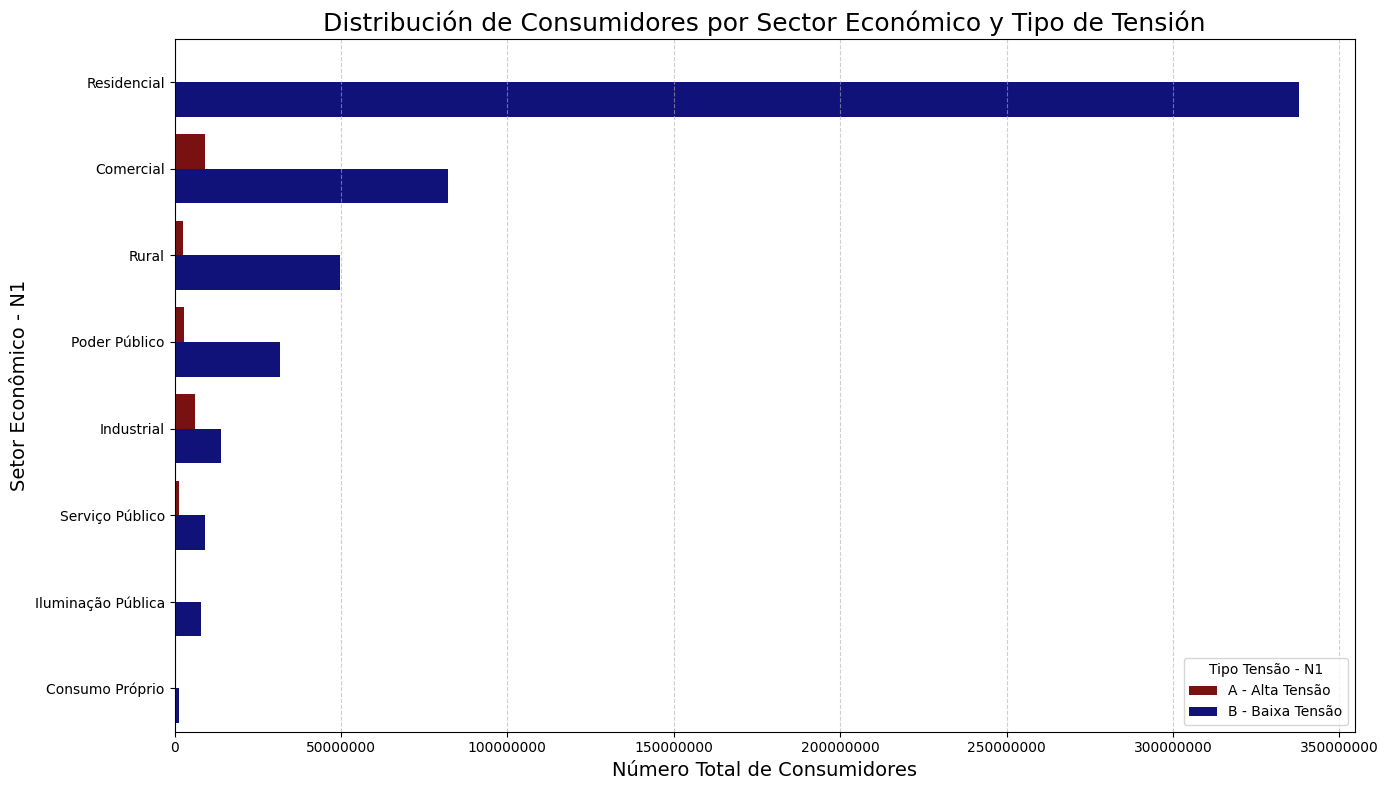


--- 11. Proporción de Consumidores por Rango de Consumo (Faixa de Consumo N1) ---


/tmp/ipykernel_5512/114422885.py:393: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


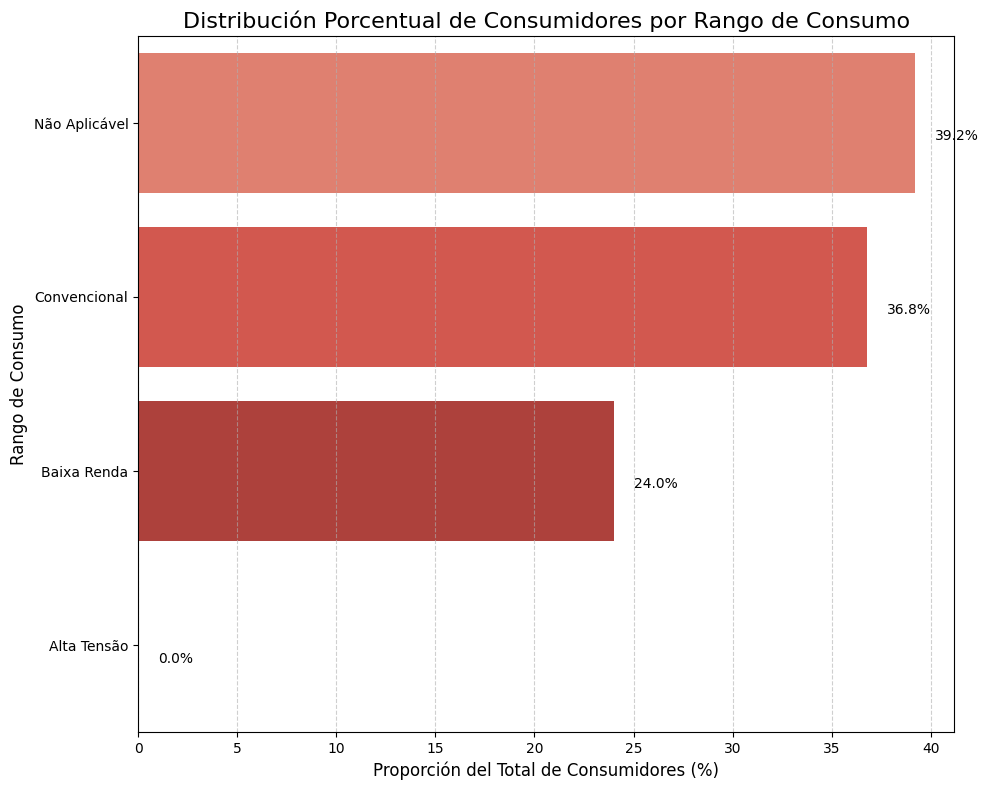


--- 12. Dinámica de Crecimiento: Evolución de Consumidores por Rango (Faixa de Consumo N1) ---


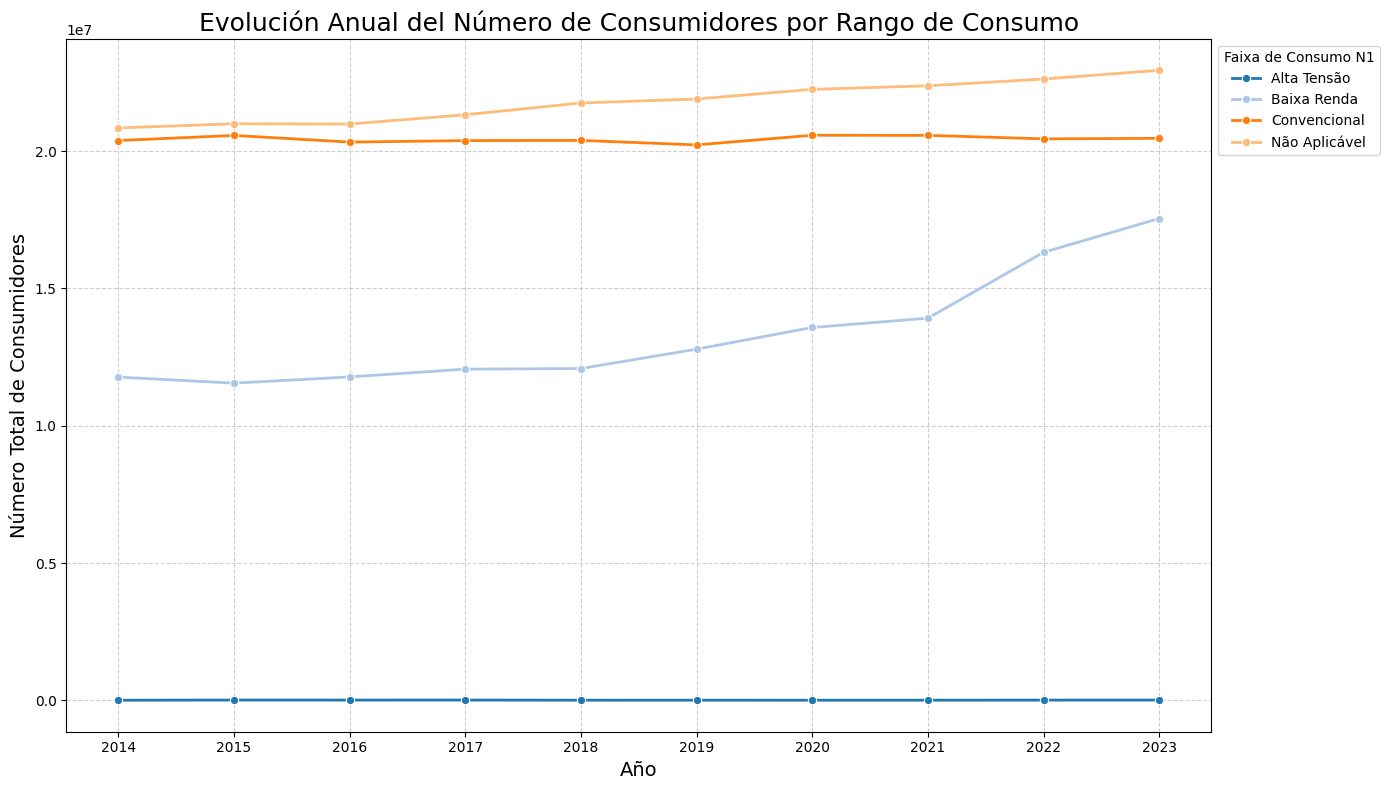

In [26]:
df_limpio = clean_01.df_eb
analizador = EnergyAnalyzer(df_limpio)
analizador.analizar_temporalidad()
analizador.comparar_estacionalidad_tension()
analizador.analizar_geografia()
analizador.analizar_mix_clientes()
analizador.analizar_proporcion_tension()
analizador.analizar_sector_consumo()
analizador.analizar_tendencia_industrial_regional(setor_n1='Industrial')
analizador.analizar_tension_por_sector()
analizador.analizar_segmentacion_clientes(columna_rango='Faixa de Consumo N1')
analizador.analizar_dinamica_crecimiento(columna_rango='Faixa de Consumo N1')

# CONCLUSION GENERAL

El mercado eléctrico muestra un crecimiento robusto pero está marcado por una extrema polarización de valor y riesgo.

### 1. Eje de valor y Riesgo de ingresos (Alta Tension).
+ Menos del 5% de los clientes (Alta tension: industria, servicios publicos) generan mas del 50 % del consumo.
+ La retencion y gestion del riesgo en el sector industrial y en las tres UF dominantes (SP, MG, RJ) son maxima prioridad para asegurar los ingresos.

### 2. Eje operacional y Social (Baja Tension)
+ **Pico de demanda**: los picos estacionales de la red son causados por la enorme base de clientes de **baja tension** (Residencian/Comercial) en los meses calidos (verano).
+ **Foco operacional**: la estrategia debe enfocarse en la eficiencia en la distribucion y la gestion de la demanda para aplanar esos picos.
+ **Crecimiento de clientes**: el crecimiento de la base de clientes se origina en los extremos: la rapida expansion de la Tarifa Social(baixa renda) y la expansion del Mercado Libre(Nao Aplicabel). El mercado regular estandar esta estancado.

**Accion Clave**
La empresa debe mantener una gestion dual: alta especializacion y servicio para el 5% de los clientes de alto valor y alta eficiencia operativa y responsabilidad social para el 95% restante.
